# PQD CNN Classifier. Training, Saving, Loading, Evaluating and TFLite Converting

In [1]:
import sys
print(sys.executable)

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Scripts\python.exe


In [2]:
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

import numpy as np
import os
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

import config
import dataset
import models
import training
import utils

## Loading Model Weights

In [3]:
settings = config.load_config('base_config.yaml')

X_train, Y_train, X_test, Y_test, encoder, metadata = dataset.loadMatlabDataset(settings['dataset'])

model_cfg = settings['model']
model_cfg.update({'input_shape': (metadata['observations'], 1), 'outputs': metadata['classes']})

model = models.build_model(settings['model'])

experiment_path = utils.set_timestamp_dir()
weights_path = utils.MODELS_DIR / 'run_08_15-13_56' / 'model.weights.h5'

Reading config yaml
Loading dataset from C:\Users\nxf93627\PQD Classifier\data\16pqd_480pattern_50hz_10cycle_noNoise.mat
Successfully read 7680 samples
Encoding labels with OneHot
Successfully encoded 16 categories
Splitted training (0.9) and testing sets (0.1)


In [4]:
model.load_weights(weights_path)

C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 47 variables. 
  saveable.load_own_variables(store)


## New functions for training.py

This is an example of Panda's DataFrame. It helps create my custom dataframe

In [5]:
data = {
    "Metric": ["Accuracy", "Recall"],
    "Value": [0.80, 0.81]
}

df = pd.DataFrame(data)
print(df)

     Metric  Value
0  Accuracy   0.80
1    Recall   0.81


In [6]:
def create_markdown(results : list, path : Path):
    '''Writes a MarkDown file for experimentation results

    Parameters:
    results (list): Macro F1 and Classification in MD format
    path (Path): Experimentation path where this will be stored
    '''
    with open(path / "README.md", "w", encoding="utf-8") as file:
        print("# Experimentation results\n", file=file)
        print(results[0], '\n', file=file)
        print(results[1], '\n', file=file)
        print('# Annotations\n', file=file)
        
def get_macrof1(Y_test, Y_pred, categories):
    '''Evaluate Macro F1 and Classification metrics of predictions
    
    Parameters:
    Y_test (array): Classification true labels
    Y_pred (array): Classification prediction labels
    categories (): Categories names

    
    '''
    accuracy = accuracy_score(Y_test, Y_pred)
    macro_f1 = f1_score(Y_test, Y_pred, average="macro")
    weighted_f1 = f1_score(Y_test, Y_pred, average="weighted")

    # Create dictionary prior to dataframe
    macrof_dict = {
        'Metric': ['Accuracy', 'Macro F1', 'Weighted F1'],
        'Value': [accuracy, macro_f1, weighted_f1]
    }

    # Create dataframe and round values to 2 decimal values
    macrof_df = pd.DataFrame(macrof_dict).round(2)
    
    report_dict = classification_report(
        Y_test, Y_pred, target_names=categories, output_dict=True)

    report_df = pd.DataFrame(report_dict).transpose().round(2)

    # Print results, useful when they will not be stored
    print(macrof_df)
    print(report_df)
    
    return [macrof_df.to_markdown(), report_df.to_markdown()]

def evaluate(model, X_test, Y_test, categories, path : Path = None):
    '''Evaluate Keras model and print confusion matrix
    
    Parameters:
    model (keras.Model): NN architecture to evaluate
    X_test (array): Signal inputs
    Y_test (array): Classification true labels
    categories (): Categories names
    path (Path): Optional path to save the results
    '''
    score = model.evaluate(X_test, Y_test, verbose=0)
    
    Y_pred = np.round(model.predict(X_test))
    results = get_macrof1(Y_test, Y_pred, categories)

    if path:
        create_markdown(results, path)

        cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))

        plt.figure(figsize=(7, 7))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=categories,
            yticklabels=categories
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix: 1D-CNN")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(path / 'confusion matrix.png')

        print('Successfully wrote \'confusion matrix.png\'')

    return model

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step


C:\Users\nxf93627\Projects\PQD-Classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


        Metric  Value
0     Accuracy    0.8
1     Macro F1    0.8
2  Weighted F1    0.8
                        precision  recall  f1-score  support
Flicker                      0.94    0.65      0.77     48.0
Flicker+Harmonics            1.00    1.00      1.00     48.0
Flicker+Sag                  0.96    0.94      0.95     48.0
Flicker+Swell                0.73    0.98      0.84     48.0
Harmonics                    0.92    1.00      0.96     48.0
Impulsive Transient          1.00    0.69      0.81     48.0
Interruption                 0.52    0.50      0.51     48.0
Interruption+Harmonics       0.44    0.48      0.46     48.0
Normal                       0.83    1.00      0.91     48.0
Notch                        0.98    0.98      0.98     48.0
Oscillatory transient        1.00    0.92      0.96     48.0
Sag                          0.49    0.35      0.41     48.0
Sag+Harmonics                0.50    0.35      0.41     48.0
Spike                        0.92    0.94      0.93     48

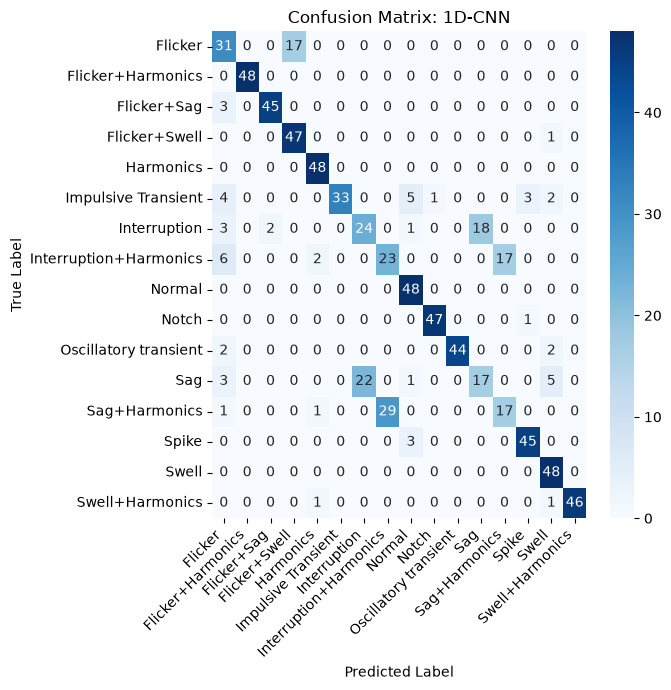

In [7]:
model = evaluate(model, X_test, Y_test, metadata['categories'], experiment_path)

In [10]:
! pip install tabulate


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
